Generate synthetic vector embeddings

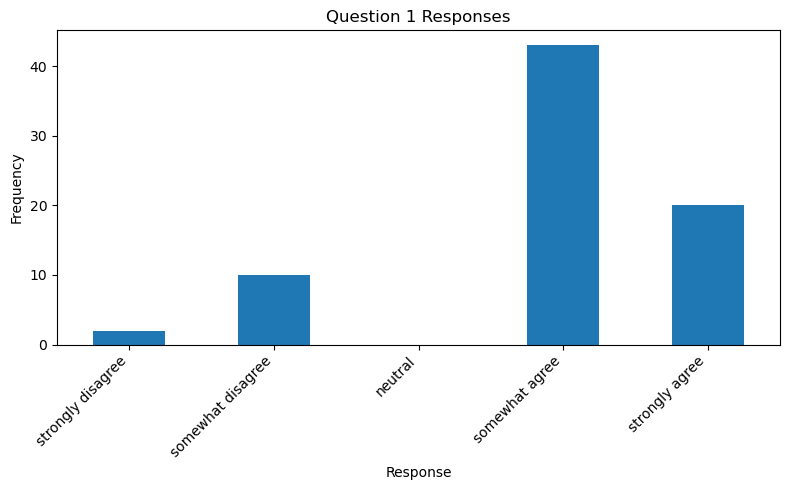

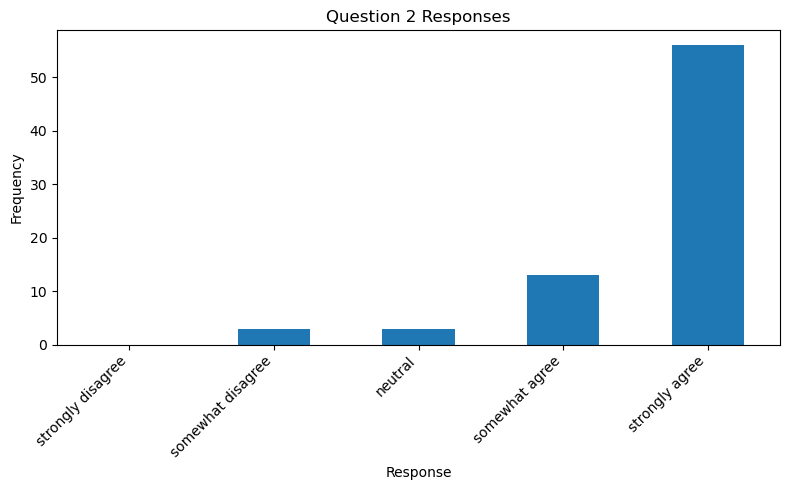

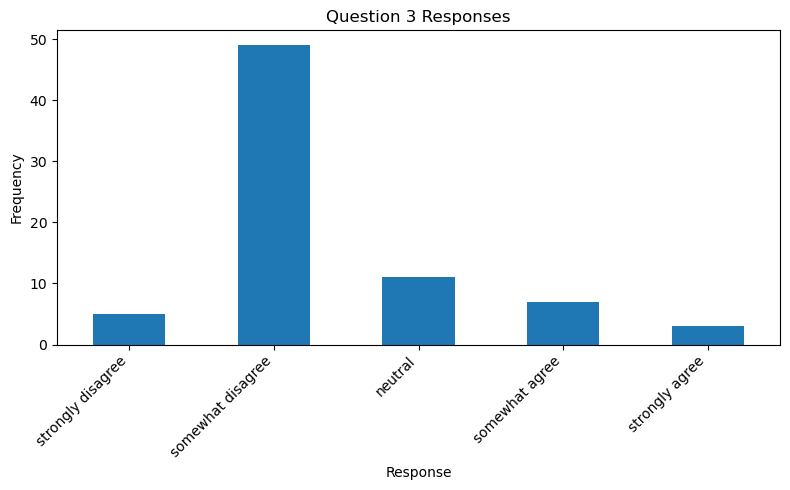

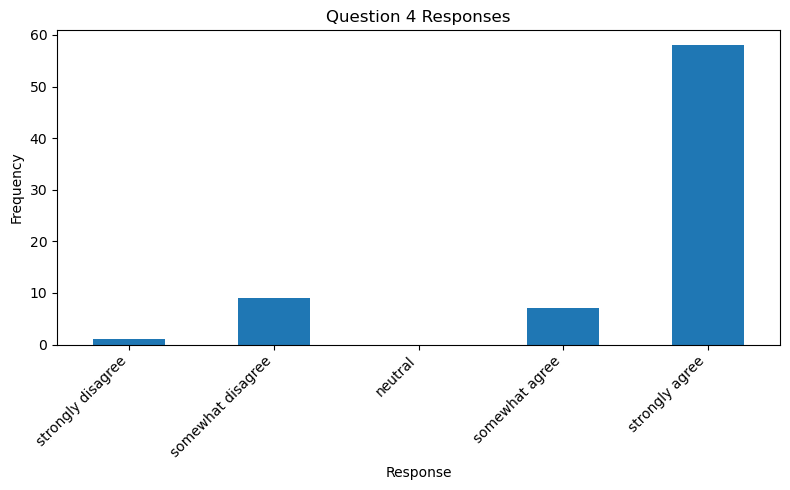

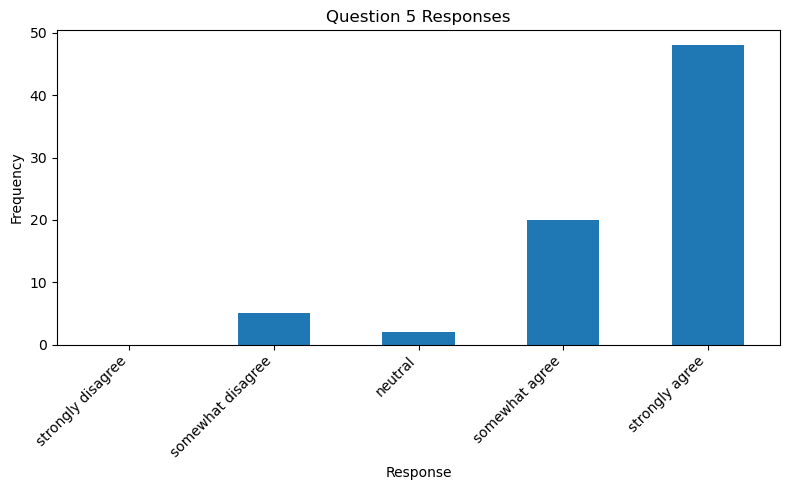

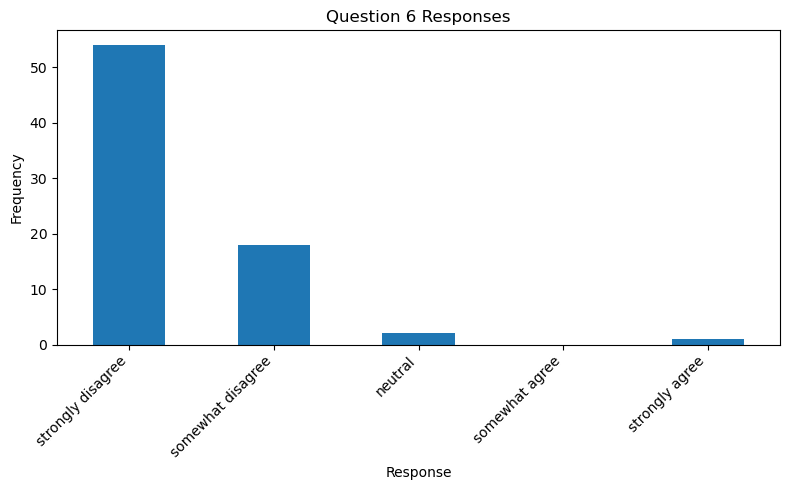

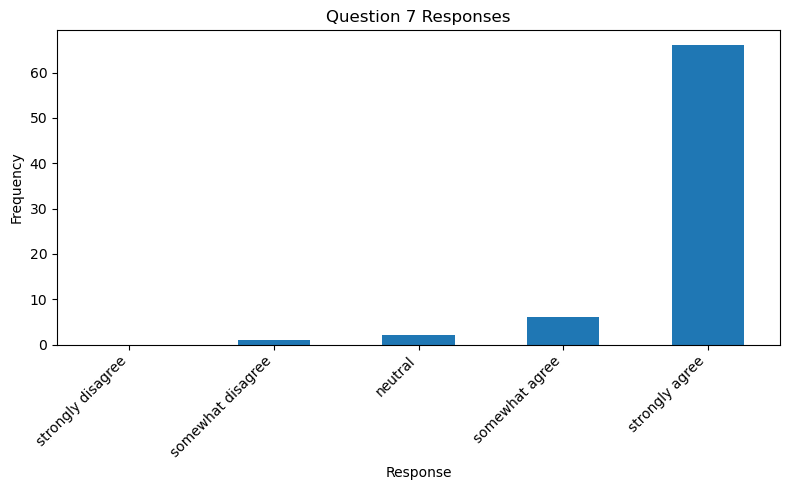

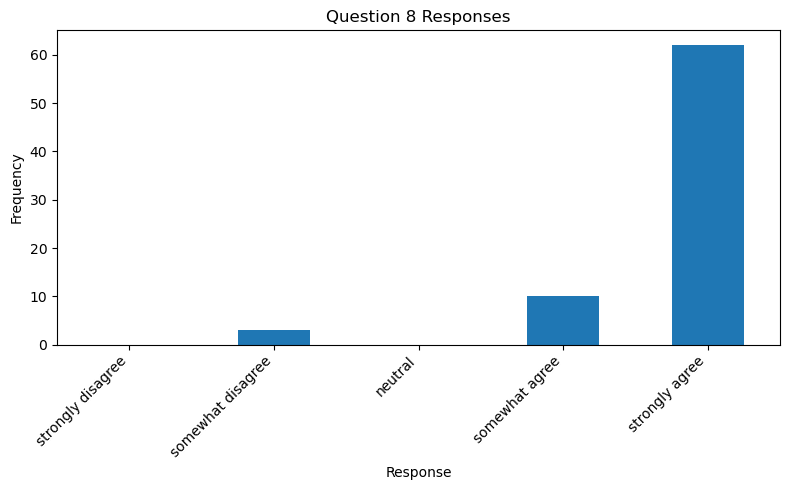

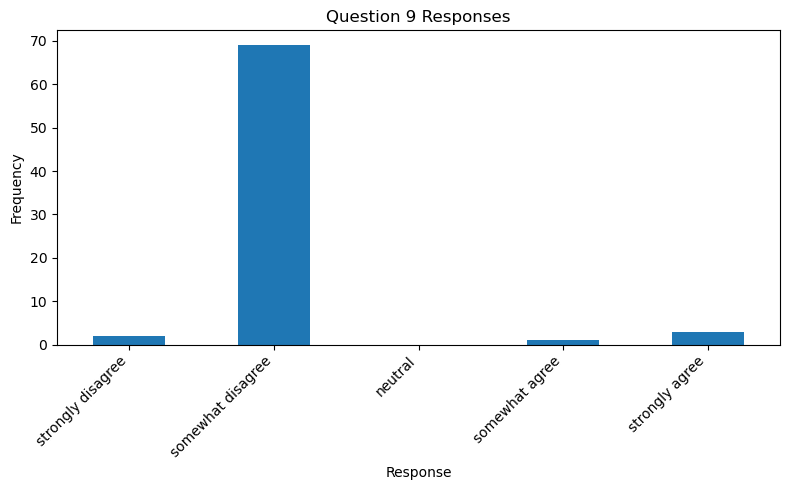

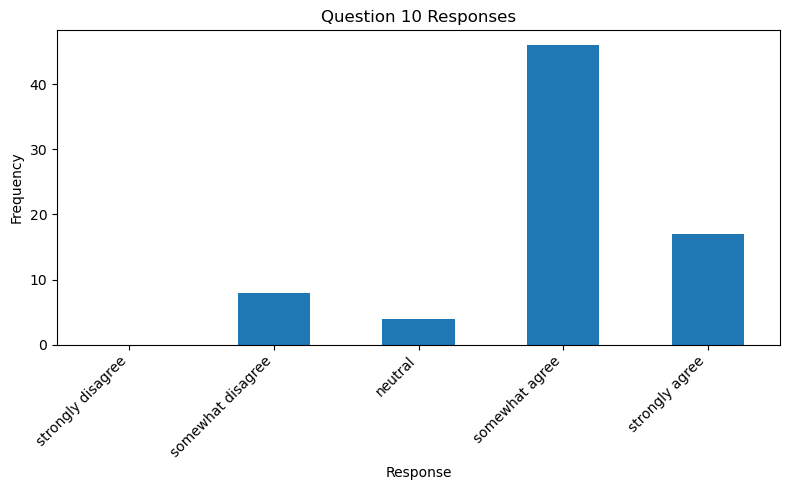

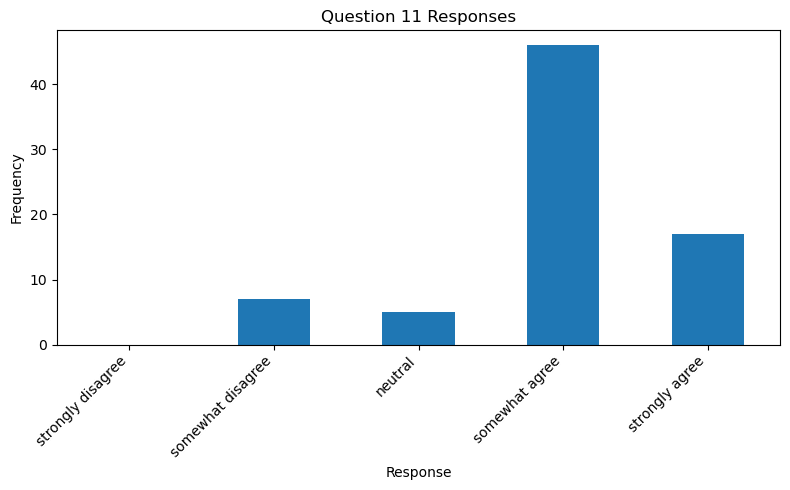

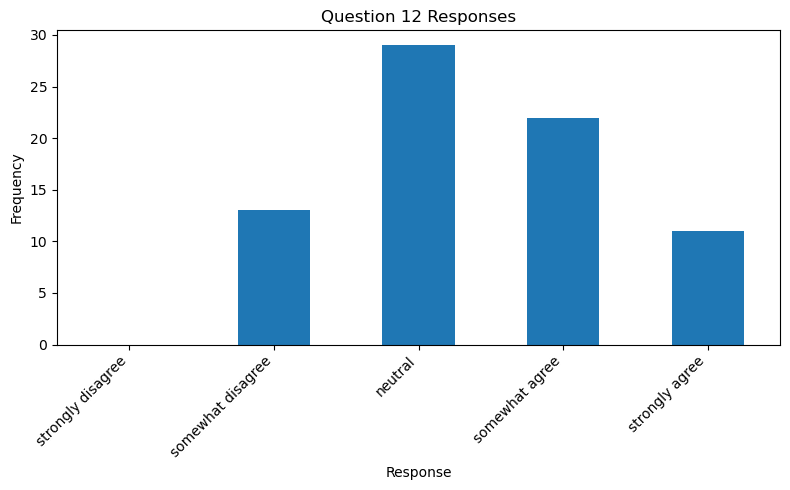

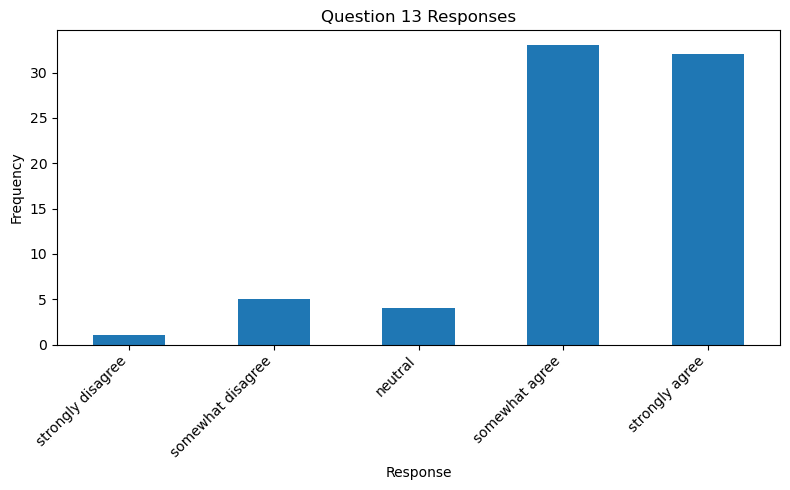

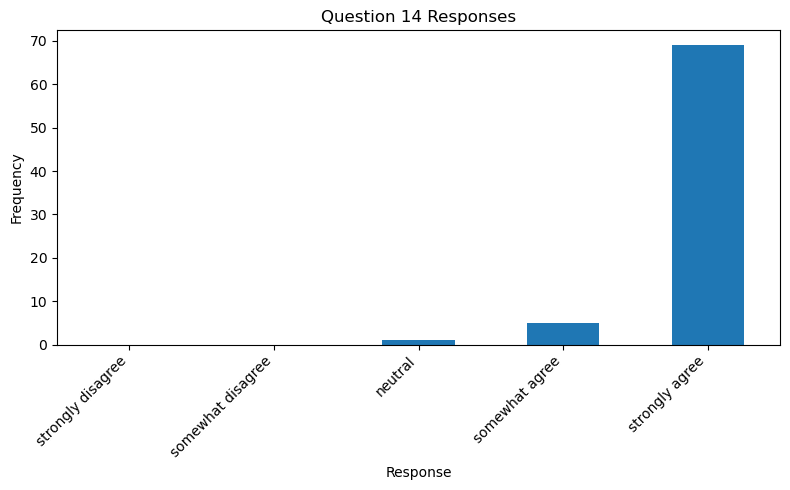

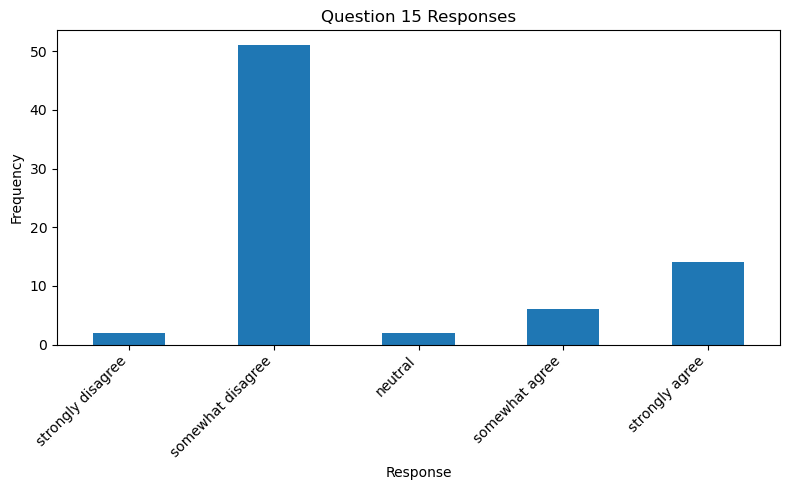

/var/folders/09/4h25jfnn06q73576vknj8hz40000gn/T/ipykernel_55758/1132650983.py:160: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  vectors = df.drop(columns=["Leader", "Type"]).replace(mapping).to_numpy()


In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


def cosine_similarity(vector, vectors):
    dot_products = vectors @ vector
    norms = np.linalg.norm(vectors, axis=1) * np.linalg.norm(vector)
    return dot_products / norms


def rank_types_by_similarity(new_vector, vectors, df):
    cosine_similarities = cosine_similarity(new_vector, vectors)

    type_vectors = {}
    for pokemon_type in df["Type"].unique():
        mask = df["Type"] == pokemon_type
        weights = cosine_similarities[mask]

        if np.sum(weights) == 0:
            type_vectors[pokemon_type] = np.mean(vectors[mask], axis=0)
        else:
            type_vectors[pokemon_type] = np.average(vectors[mask], axis=0, weights=weights)

    scores = {pokemon_type: vec.mean() for pokemon_type, vec in type_vectors.items()}
    ranking = pd.Series(scores).sort_values(ascending=False)
    return ranking


def plot_pca(new_vector, vectors, df):
    """
    Project gym leader vectors + the new vector into 2D via PCA.
    Each point is colored by Pokémon type; the new vector is shown as a star.
    """
    all_vectors = np.vstack([vectors, new_vector])

    pca = PCA(n_components=2)
    projected = pca.fit_transform(all_vectors)

    leader_proj = projected[:-1]
    new_proj = projected[-1]

    types = df["Type"].unique()
    cmap = plt.cm.get_cmap("tab20", len(types))
    type_to_color = {t: cmap(i) for i, t in enumerate(types)}

    fig, ax = plt.subplots(figsize=(9, 6))

    for pokemon_type in types:
        mask = df["Type"] == pokemon_type
        ax.scatter(
            leader_proj[mask, 0],
            leader_proj[mask, 1],
            label=pokemon_type,
            color=type_to_color[pokemon_type],
            s=80,
            alpha=0.85,
        )

    ax.scatter(
        new_proj[0], new_proj[1],
        marker="*", s=300, color="black", zorder=5, label="New vector"
    )

    var_explained = pca.explained_variance_ratio_ * 100
    ax.set_xlabel(f"PC1 ({var_explained[0]:.1f}% variance)")
    ax.set_ylabel(f"PC2 ({var_explained[1]:.1f}% variance)")
    ax.set_title("PCA of gym leader vectors")
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_similarity_heatmap(vectors, df):
    """
    Compute cosine similarity between each gym leader and each type centroid,
    rendered as an annotated heatmap (types × leaders).
    """
    type_centroids = {}
    for pokemon_type in df["Type"].unique():
        mask = df["Type"] == pokemon_type
        type_centroids[pokemon_type] = vectors[mask].mean(axis=0)

    types = list(type_centroids.keys())
    centroids = np.array([type_centroids[t] for t in types])

    # Normalize rows before dot product for cosine similarity
    def safe_normalize(mat):
        norms = np.linalg.norm(mat, axis=1, keepdims=True)
        return mat / np.where(norms == 0, 1, norms)

    norm_centroids = safe_normalize(centroids)
    norm_vectors = safe_normalize(vectors)

    sim_matrix = norm_centroids @ norm_vectors.T  # shape: (n_types, n_leaders)

    leaders = df["Leader"].tolist()
    n_types = len(types)
    n_leaders = len(leaders)

    fig, ax = plt.subplots(figsize=(max(8, n_leaders * 0.6), max(5, n_types * 0.55)))
    im = ax.imshow(sim_matrix, vmin=-1, vmax=1, cmap="RdYlGn", aspect="auto")

    plt.colorbar(im, ax=ax, label="Cosine similarity")

    ax.set_xticks(range(n_leaders))
    ax.set_yticks(range(n_types))
    ax.set_xticklabels(leaders, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(types, fontsize=8)

    for i in range(n_types):
        for j in range(n_leaders):
            ax.text(j, i, f"{sim_matrix[i, j]:.2f}", ha="center", va="center",
                    fontsize=6, color="black")

    ax.set_title("Gym leader vs type cosine similarity")
    ax.set_xlabel("Gym leader")
    ax.set_ylabel("Type")
    plt.tight_layout()
    plt.show()

def plot_ranking(ranking):
    fig, ax = plt.subplots(figsize=(9, 6))
    ranking.plot(kind="bar", ax=ax)
    ax.set_xlabel("Type")
    ax.set_ylabel("Average Similarity")
    ax.set_title("Ranking of Types by Similarity to New Vector")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()



# --- Main ---
mapping = {
    "strongly disagree": -1,
    "somewhat disagree": -0.5,
    "neutral": 0,
    "somewhat agree": 0.5,
    "strongly agree": 1
}

df = pd.read_csv("api/gym_leaders.csv")

for i in range(1, 16):
    plt.figure(figsize=(8, 5))
    
    # Get counts for all possible values (using original string values)
    counts = df[f'Q{i}'].str.lower().value_counts().reindex(mapping.keys(), fill_value=0)
    counts.plot(kind="bar")
    plt.gca().set_xticklabels(list(mapping.keys()), rotation=45, ha='right')
    plt.title(f'Question {i} Responses')
    plt.xlabel('Response')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

# THEN do the replacement for vectors
vectors = df.drop(columns=["Leader", "Type"]).replace(mapping).to_numpy()

new_vector = np.random.choice(list(mapping.values()), size=15)

ranking = rank_types_by_similarity(new_vector, vectors, df)


In [64]:
import pandas as pd
mapping = {
    "strongly disagree": -1,
    "somewhat disagree": -0.5,
    "neutral": 0,
    "somewhat agree": 0.5,
    "strongly agree": 1
}

df = pd.read_csv("api/gym_leaders.csv")
df = df.replace(mapping)
df

/var/folders/09/4h25jfnn06q73576vknj8hz40000gn/T/ipykernel_55758/1969853484.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(mapping)


,Leader,Type,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Q11,Q12,Q13,Q14,Q15
0,Brock,Rock,0.5,0.5,0.0,1.0,1.0,-1.0,1.0,1.0,-0.5,1.0,-0.5,0.5,0.5,1.0,1.0
1,Misty,Water,0.5,1.0,-0.5,1.0,0.5,-0.5,1.0,0.5,-0.5,0.5,0.5,0.5,1.0,1.0,-0.5
2,Lt. surge,Electric,1.0,1.0,-1.0,0.5,-0.5,-0.5,1.0,1.0,-1.0,0.5,1.0,0.5,1.0,0.5,-0.5
3,Erika,Grass,0.5,1.0,-0.5,1.0,1.0,-1.0,1.0,1.0,-0.5,1.0,0.5,0.0,0.5,1.0,1.0
4,Koga,Poison,-1.0,0.5,1.0,1.0,1.0,-1.0,1.0,1.0,-1.0,1.0,0.5,1.0,-1.0,1.0,-0.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,Kofu,Water,0.5,1.0,-0.5,1.0,1.0,-1.0,1.0,1.0,-0.5,0.5,0.5,0.0,1.0,1.0,-0.5
71,Larry,Normal,0.5,1.0,-0.5,1.0,1.0,-1.0,1.0,1.0,-0.5,1.0,0.0,-0.5,0.5,1.0,1.0
72,Ryme,Ghost,0.5,1.0,-0.5,1.0,1.0,-1.0,1.0,1.0,-0.5,0.5,0.5,0.0,1.0,1.0,-0.5
73,Tulip,Psychic,1.0,0.5,-0.5,-0.5,0.0,-1.0,1.0,0.5,-0.5,0.5,0.5,0.5,1.0,1.0,-0.5


In [65]:
from itertools import combinations_with_replacement 
import numpy as np

all_possible_vectors = list(combinations_with_replacement(mapping.values(), 15))
all_possible_vectors = [np.array(vector) for vector in all_possible_vectors]
all_possible_vectors = np.array(all_possible_vectors)
# for vector in all_possible_vectors:
#     print(vector)

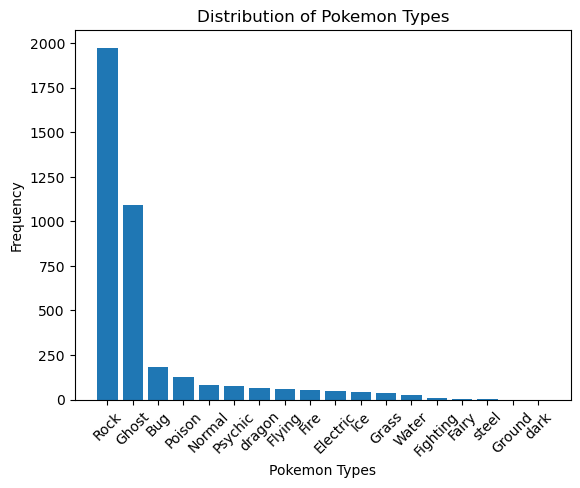

In [66]:
def cosine_similarity(vector, vectors):
    dot_products = vectors @ vector
    norms = np.linalg.norm(vectors, axis=1) * np.linalg.norm(vector)
    with np.errstate(divide='ignore', invalid='ignore'):
        similarities = dot_products / norms
    similarities = np.nan_to_num(similarities, nan=0.0)
    return similarities


def rank_types_by_similarity(new_vector, df):
    vectors = df[[f"Q{i+1}" for i in range(15)]].values
    cosine_similarities = cosine_similarity(new_vector, vectors)

    type_vectors = {}
    for pokemon_type in df["Type"].unique():
        mask = df["Type"] == pokemon_type
        weights = cosine_similarities[mask]

        if np.sum(weights) == 0:
            type_vectors[pokemon_type] = np.mean(vectors[mask], axis=0)
        else:
            type_vectors[pokemon_type] = np.average(
                vectors[mask], axis=0, weights=weights)

    scores = {pokemon_type: vec.mean()
              for pokemon_type, vec in type_vectors.items()}
    ranking = pd.Series(scores).sort_values(ascending=False)
    return ranking

types = df.Type.unique()
types = {type: 0 for type in types}

for v in all_possible_vectors:
    ranking = rank_types_by_similarity(v, df)
    for t in types:
        if ranking.keys()[0] == t:
            types[t] += 1

import matplotlib.pyplot as plt
types = dict(sorted(types.items(), key=lambda item: item[1], reverse=True))
plt.bar(types.keys(), types.values())
plt.xlabel("Pokemon Types")
plt.ylabel("Frequency")
plt.title("Distribution of Pokemon Types")
plt.xticks(rotation=45)
plt.show()

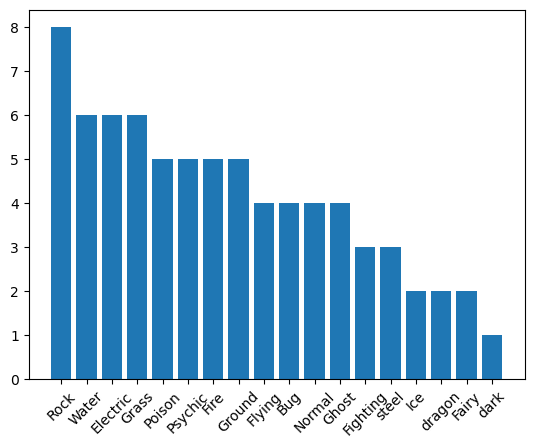

In [67]:
plt.bar(df.Type.unique(), df.Type.value_counts())
plt.xticks(rotation=45)
plt.show()

/var/folders/09/4h25jfnn06q73576vknj8hz40000gn/T/ipykernel_55758/1132650983.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(types))


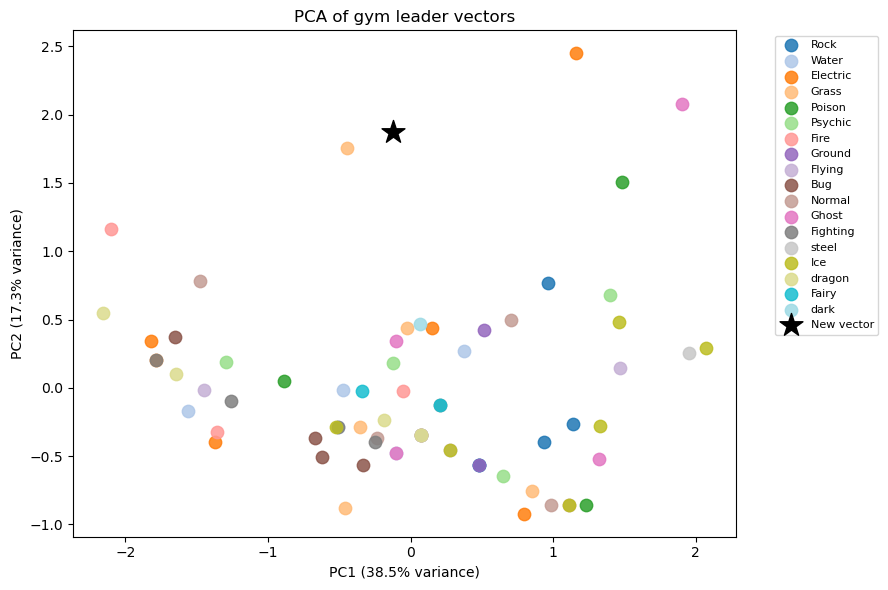

In [68]:
plot_pca(np.zeros(15), vectors, df)

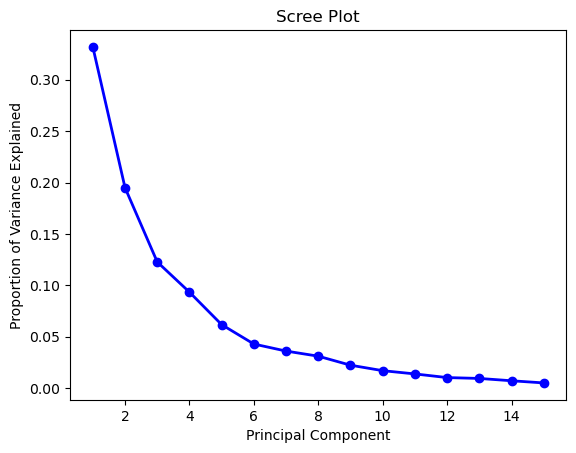

In [69]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Standardize your data (crucial for PCA)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(vectors)

# 2. Perform PCA
pca = PCA()
pca.fit(scaled_data)

# 3. Get variance details
PC_values = np.arange(pca.n_components_) + 1
variance_ratio = pca.explained_variance_ratio_

# 4. Create Scree Plot
plt.plot(PC_values, variance_ratio, 'o-', linewidth=2, color='blue')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Proportion of Variance Explained')
plt.show()


/var/folders/09/4h25jfnn06q73576vknj8hz40000gn/T/ipykernel_55758/1604602453.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  vectors = df.drop(columns=['Leader']).replace(mapping).groupby("Type").mean()
/var/folders/09/4h25jfnn06q73576vknj8hz40000gn/T/ipykernel_55758/1604602453.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(types))


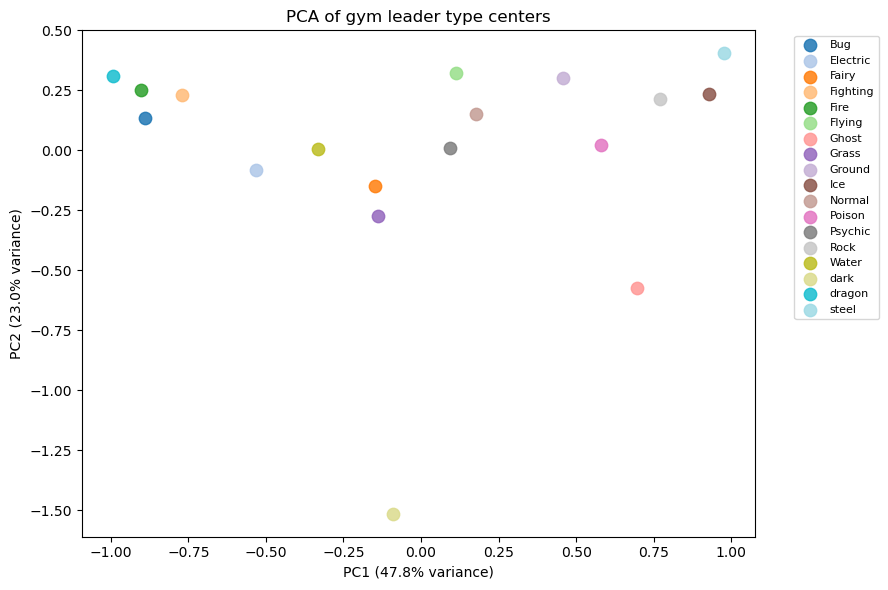

In [79]:
def plot_pca_types(df):
    vectors = df.drop(columns=['Leader']).replace(mapping).groupby("Type").mean()
    # `vectors` index is now the type names, one row per type

    pca = PCA(n_components=2)
    projected = pca.fit_transform(vectors)

    # All rows are type centers now — no "new vector" row to split off
    # (remove the leader_proj/new_proj split unless you're appending a new vector separately)
    type_centers = projected          # shape: (n_types, 2)
    types = vectors.index.tolist()    # type names aligned with projected rows

    cmap = plt.cm.get_cmap("tab20", len(types))
    type_to_color = {t: cmap(i) for i, t in enumerate(types)}

    fig, ax = plt.subplots(figsize=(9, 6))

    for i, pokemon_type in enumerate(types):
        ax.scatter(
            type_centers[i, 0],      # single point per type
            type_centers[i, 1],
            label=pokemon_type,
            color=type_to_color[pokemon_type],
            s=80,
            alpha=0.85,
        )

    var_explained = pca.explained_variance_ratio_ * 100
    ax.set_xlabel(f"PC1 ({var_explained[0]:.1f}% variance)")
    ax.set_ylabel(f"PC2 ({var_explained[1]:.1f}% variance)")
    ax.set_title("PCA of gym leader type centers")
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()

df = pd.read_csv("api/gym_leaders.csv")

plot_pca_types(df)

/var/folders/09/4h25jfnn06q73576vknj8hz40000gn/T/ipykernel_55758/1626181084.py:41: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  numeric_df = df.drop(columns=['Leader', 'Type']).replace(mapping)


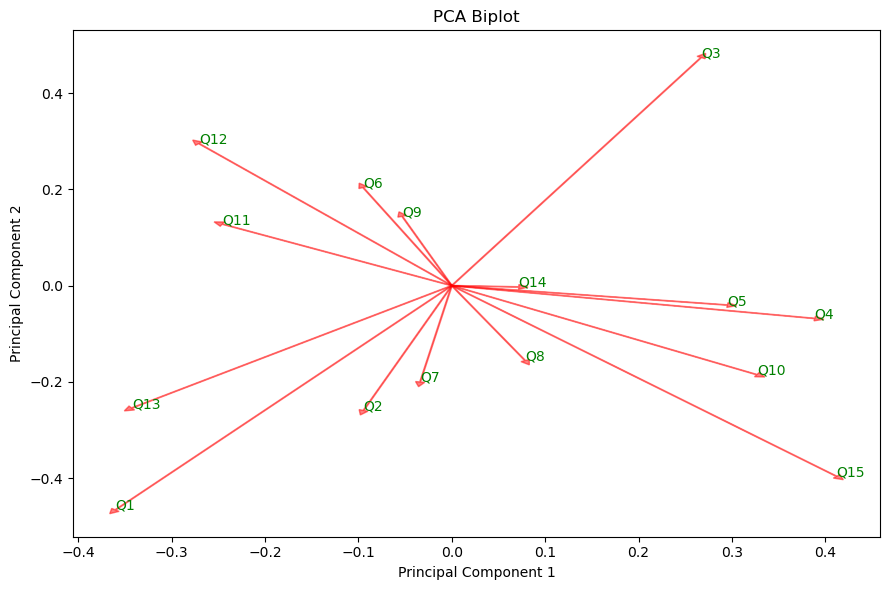

In [91]:
def pca_biplot(features, pca):
    """
    Create and plot a Biplot of Principal Component 2's effect of Principal Component 1 (check for error)

    :param: None 

    :return: None 
    """

    # Visualize PCA biplot
    fig, ax1 = plt.subplots(1, 1, figsize=(9, 6), tight_layout=True)

    # Iterate over features to plot arrows and labels on the biplot
    for i, feature in enumerate(features):
        # Plot arrows representing feature contributions to PC1 and PC2
        ax1.arrow(
            x=0,
            y=0,
            dx=pca.components_[0, i],
            dy=pca.components_[1, i],
            color='r',
            alpha=0.5,
            head_width=0.01,
            head_length=0.01,
        )
        # Annotate each arrow with the corresponding feature name
        ax1.text(
            pca.components_[0, i],
            pca.components_[1, i],
            feature,
            color='g'
        )
    # Set axes properties
    ax1.set_xlabel('Principal Component 1')
    ax1.set_ylabel('Principal Component 2')
    ax1.set_title('PCA Biplot')

    # Display the biplot
    plt.show()

numeric_df = df.drop(columns=['Leader', 'Type']).replace(mapping)
pca = PCA(n_components=2)
pca.fit(numeric_df)

features = numeric_df.columns.tolist()
pca_biplot(features, pca)

In [93]:
import json
from itertools import combinations_with_replacement
import numpy as np
import pandas as pd

mapping = {
    "strongly disagree": -1,
    "somewhat disagree": -0.5,
    "neutral": 0,
    "somewhat agree": 0.5,
    "strongly agree": 1
}

def cosine_similarity(vector, vectors):
    dot_products = vectors @ vector
    norms = np.linalg.norm(vectors, axis=1) * np.linalg.norm(vector)
    return dot_products / norms

def rank_types_by_similarity(new_vector, vectors, df):
    cosine_similarities = cosine_similarity(new_vector, vectors)
    
    type_vectors = {}
    for pokemon_type in df["Type"].unique():
        mask = df["Type"] == pokemon_type
        weights = cosine_similarities[mask]
        
        if np.sum(weights) == 0:
            type_vectors[pokemon_type] = np.mean(vectors[mask], axis=0)
        else:
            type_vectors[pokemon_type] = np.average(vectors[mask], axis=0, weights=weights)
    
    scores = {pokemon_type: vec.mean() for pokemon_type, vec in type_vectors.items()}
    ranking = pd.Series(scores).sort_values(ascending=False)
    return ranking

# Load your reference data here
df = pd.read_csv("api/gym_leaders.csv")
vectors = df.drop(columns=['Leader', 'Type']).replace(mapping)

# Generate all possible answer combinations
all_possible_vectors = list(combinations_with_replacement(mapping.values(), 15))
all_possible_vectors = [np.array(vector) for vector in all_possible_vectors]

# Build the results map
results_map = {}
for vector in all_possible_vectors:
    key = ','.join(map(str, vector))
    ranking = rank_types_by_similarity(vector, vectors, df)
    results_map[key] = ranking.index[0]  # Get the top-ranked type

print(f"Generated {len(results_map)} combinations")

# Export to JSON
with open('quiz_results.json', 'w') as f:
    json.dump(results_map, f, indent=2)

print("Successfully created quiz_results.json!")

/var/folders/09/4h25jfnn06q73576vknj8hz40000gn/T/ipykernel_55758/1473224349.py:38: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  vectors = df.drop(columns=['Leader', 'Type']).replace(mapping)


Generated 3876 combinations
Successfully created quiz_results.json!
